<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Copy_of_Assignment_1_Analyzing_Train_Arrivals_Using_Poisson_Distribution_Ulrich.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Poisson Distribution — Train Arrivals at a Station
**Assignment:** Apply the Poisson distribution to model and forecast train arrivals  
**Tools:** NumPy · SciPy · Seaborn · Matplotlib  
**Google Colab compatible** — run all cells in order


---
## Step 1: Setup the Environment

In [ ]:
# ── Import all necessary libraries ───────────────────────────────────────────
import numpy as np                        # Numerical computing
import pandas as pd                       # Data manipulation
import matplotlib.pyplot as plt           # Base plotting
import seaborn as sns                     # Statistical visualizations
from scipy.stats import poisson           # Poisson distribution functions

# ── Set random seed for reproducibility ──────────────────────────────────────
np.random.seed(42)

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✓ Libraries imported and random seed set (seed = 42)")


✓ Libraries imported and random seed set (seed = 42)


---
## Step 2: Initial Observations
Create 20 observations representing train arrivals per hour over a 20-hour period.

In [ ]:
# ── Create initial observations ───────────────────────────────────────────────
# 20 hourly counts of trains arriving at the station
initial_obs = np.array([7, 9, 8, 10, 6, 11, 8, 9, 7, 10,
                          9, 8, 11, 7, 9, 10, 8, 9, 7, 10])

print(f"Number of observations : {len(initial_obs)}")
print(f"Observations           : {initial_obs}")
print(f"Min / Max              : {initial_obs.min()} / {initial_obs.max()}")
print(f"Standard deviation     : {initial_obs.std():.4f}")

# ── Calculate the mean ────────────────────────────────────────────────────────
# For Poisson distribution, the mean (λ) equals both the mean and the variance
mean_initial = np.mean(initial_obs)
print(f"\nMean (λ) of initial observations: {mean_initial}")
print(f"This is our Poisson rate parameter λ = {mean_initial} trains/hour")


Number of observations : 20
Observations           : [ 7  9  8 10  6 11  8  9  7 10  9  8 11  7  9 10  8  9  7 10]
Min / Max              : 6 / 11
Standard deviation     : 1.3883

Mean (λ) of initial observations: 8.65
This is our Poisson rate parameter λ = 8.65 trains/hour


---
## Step 3: Visualize the Distribution
Plot the distribution of initial observations and overlay the theoretical Poisson PMF.

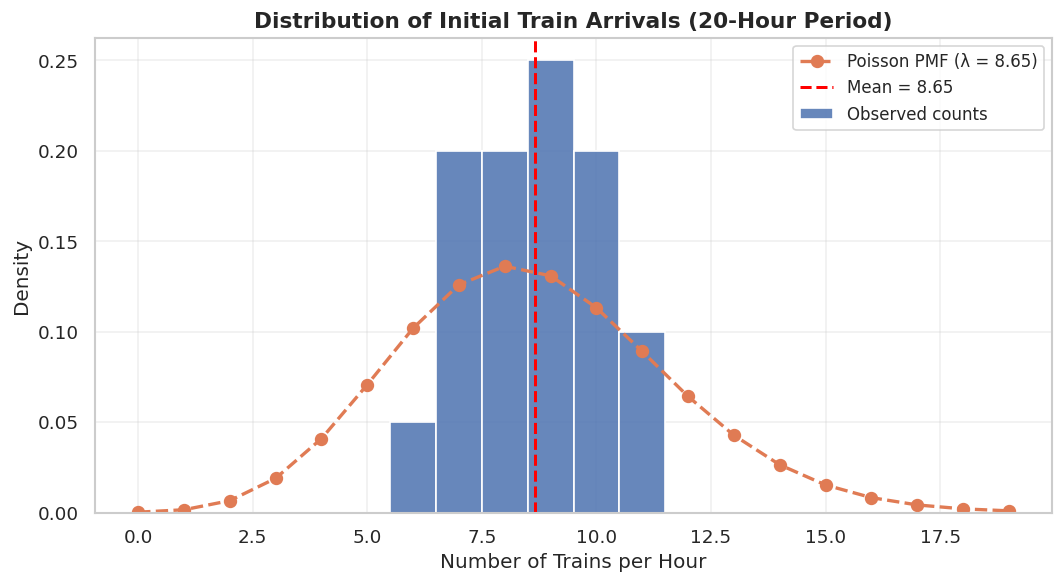

Shape: Roughly bell-shaped / right-skewed, centred around λ = 8.65


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

# ── Histogram of observed counts ──────────────────────────────────────────────
sns.histplot(initial_obs,
             bins=range(int(initial_obs.min()), int(initial_obs.max()) + 2),
             discrete=True,
             color='#4C72B0', edgecolor='white', alpha=0.85,
             stat='density', label='Observed counts', ax=ax)

# ── Theoretical Poisson PMF overlay ──────────────────────────────────────────
x_vals = range(0, 20)
ax.plot(x_vals, poisson.pmf(x_vals, mu=mean_initial),
        'o--', color='#E07B54', lw=2, ms=7,
        label=f'Poisson PMF (λ = {mean_initial})')

# ── Mean reference line ───────────────────────────────────────────────────────
ax.axvline(mean_initial, color='red', lw=1.8, linestyle='--',
           label=f'Mean = {mean_initial}')

ax.set_xlabel('Number of Trains per Hour', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Initial Train Arrivals (20-Hour Period)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Shape: Roughly bell-shaped / right-skewed, centred around λ = 8.65")


---
## Step 4: Calculate Probabilities (Initial Observations)
Using `scipy.stats.poisson.cdf`: P(X > k) = 1 − P(X ≤ k) = 1 − CDF(k, λ)

In [ ]:
print(f"Using Poisson distribution with λ = {mean_initial}\n")
print("-" * 55)
print(f"{'Threshold (k)':<20} {'P(X > k)':<20} {'Interpretation'}")
print("-" * 55)

thresholds = [9, 10, 11, 12]
probs_initial = []
for k in thresholds:
    # P(X > k) = 1 - P(X <= k) = 1 - CDF(k)
    prob = 1 - poisson.cdf(k, mu=mean_initial)
    probs_initial.append(prob)
    pct  = prob * 100
    print(f"P(X > {k:<2})            {prob:.6f}            {pct:.2f}% chance of >{k} trains")

print("-" * 55)
print(f"\nInterpretation: With λ = {mean_initial}, observing more than 12 trains")
print(f"in a single hour has only a {probs_initial[-1]*100:.2f}% probability.")


Using Poisson distribution with λ = 8.65

-------------------------------------------------------
Threshold (k)        P(X > k)             Interpretation
-------------------------------------------------------
P(X > 9 )            0.366584            36.66% chance of >9 trains
P(X > 10)            0.253409            25.34% chance of >10 trains
P(X > 11)            0.164412            16.44% chance of >11 trains
P(X > 12)            0.100260            10.03% chance of >12 trains
-------------------------------------------------------

Interpretation: With λ = 8.65, observing more than 12 trains
in a single hour has only a 10.03% probability.


---
## Step 5: New Train Schedule — Updated Observations

In [ ]:
# ── New observations: expected increase under proposed schedule ───────────────
new_obs = np.array([11, 12, 10, 13, 11, 14, 12, 11, 13, 12,
                      14, 11, 12, 13, 11, 12, 14, 13, 11, 12])

print(f"New observations (20 hours): {new_obs}")
print(f"New observations mean      : {np.mean(new_obs):.2f} trains/hour")
print(f"Increase vs initial        : +{np.mean(new_obs) - mean_initial:.2f} trains/hour")

# ── Concatenate and recalculate mean ─────────────────────────────────────────
combined_obs = np.concatenate([initial_obs, new_obs])
mean_updated = np.mean(combined_obs)

print(f"\nCombined observations ({len(combined_obs)} hours):")
print(f"  Updated mean (λ)    : {mean_updated} trains/hour")
print(f"  Combined std        : {combined_obs.std():.4f}")
print(f"  Min / Max           : {combined_obs.min()} / {combined_obs.max()}")


New observations (20 hours): [11 12 10 13 11 14 12 11 13 12 14 11 12 13 11 12 14 13 11 12]
New observations mean      : 12.10 trains/hour
Increase vs initial        : +3.45 trains/hour

Combined observations (40 hours):
  Updated mean (λ)    : 10.375 trains/hour
  Combined std        : 2.1411
  Min / Max           : 6 / 14


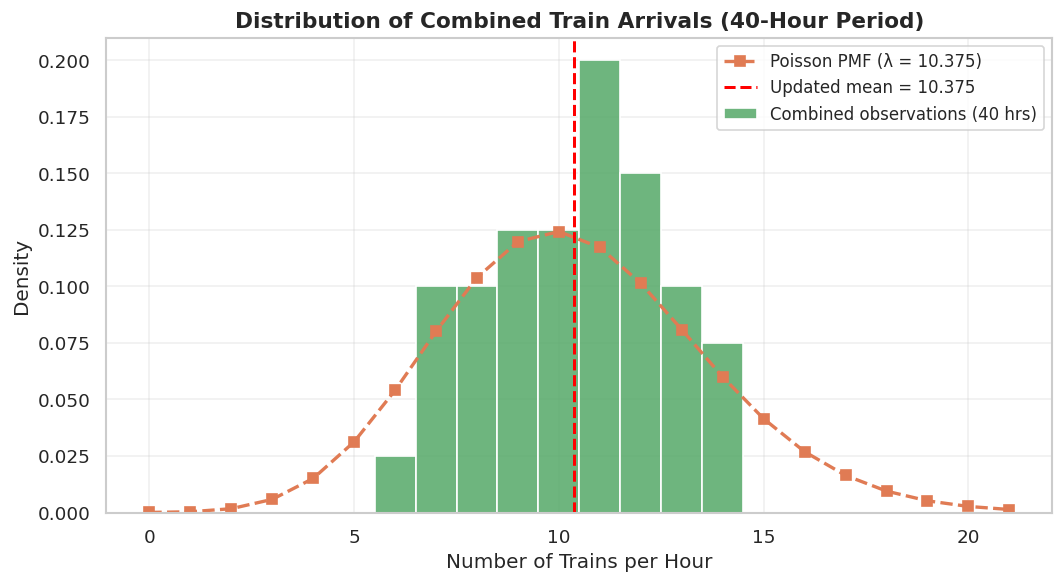

In [ ]:
# ── Visualize updated distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(combined_obs,
             bins=range(int(combined_obs.min()), int(combined_obs.max()) + 2),
             discrete=True,
             color='#55A868', edgecolor='white', alpha=0.85,
             stat='density', label='Combined observations (40 hrs)', ax=ax)

x_vals = range(0, 22)
ax.plot(x_vals, poisson.pmf(x_vals, mu=mean_updated),
        's--', color='#E07B54', lw=2, ms=6,
        label=f'Poisson PMF (λ = {mean_updated})')

ax.axvline(mean_updated, color='red', lw=1.8, linestyle='--',
           label=f'Updated mean = {mean_updated}')

ax.set_xlabel('Number of Trains per Hour', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Combined Train Arrivals (40-Hour Period)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## Step 6: Repeat Probability Analysis (Updated λ)

In [ ]:
print(f"Updated Poisson distribution with λ = {mean_updated}\n")
print("-" * 70)
print(f"{'Threshold':<12} {'Initial (λ=8.65)':<22} {'Updated (λ=10.375)':<22} {'Change'}")
print("-" * 70)

for k, p_init in zip(thresholds, probs_initial):
    p_upd = 1 - poisson.cdf(k, mu=mean_updated)
    delta = p_upd - p_init
    sign  = "+" if delta >= 0 else ""
    print(f"P(X > {k:<2})    {p_init:.6f}            {p_upd:.6f}            {sign}{delta:.6f}")

print("-" * 70)
print("\n→ The updated schedule substantially increases the probability of")
print("  high-traffic hours across all thresholds.")


Updated Poisson distribution with λ = 10.375

----------------------------------------------------------------------
Threshold    Initial (λ=8.65)       Updated (λ=10.375)     Change
----------------------------------------------------------------------
P(X > 9 )    0.366584            0.588023            +0.221440
P(X > 10)    0.253409            0.463769            +0.210360
P(X > 11)    0.164412            0.346574            +0.182162
P(X > 12)    0.100260            0.245249            +0.144989
----------------------------------------------------------------------

→ The updated schedule substantially increases the probability of
  high-traffic hours across all thresholds.


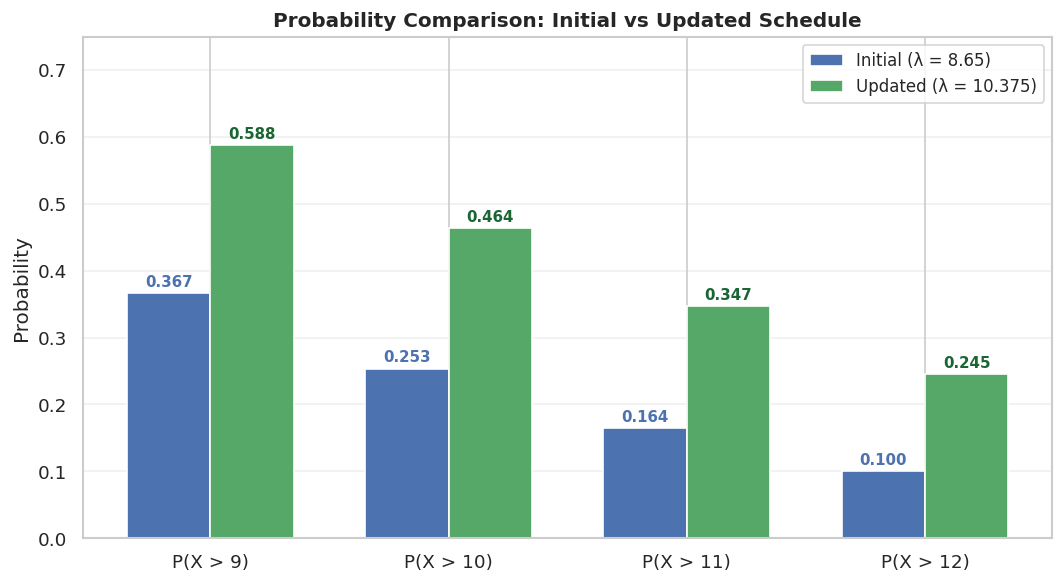

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

probs_upd = [1 - poisson.cdf(k, mu=mean_updated) for k in thresholds]
x = np.arange(len(thresholds)); w = 0.35

bars1 = ax.bar(x - w/2, probs_initial, w, color='#4C72B0',
               edgecolor='white', label=f'Initial (λ = {mean_initial})')
bars2 = ax.bar(x + w/2, probs_upd, w,  color='#55A868',
               edgecolor='white', label=f'Updated (λ = {mean_updated})')

for bar, v in zip(bars1, probs_initial):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold', color='#4C72B0')
for bar, v in zip(bars2, probs_upd):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold', color='#1a6633')

ax.set_xticks(x)
ax.set_xticklabels([f'P(X > {k})' for k in thresholds], fontsize=11)
ax.set_ylabel('Probability'); ax.set_ylim(0, 0.75)
ax.set_title('Probability Comparison: Initial vs Updated Schedule',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


---
## Step 7: Generate & Visualize Synthetic Data (n = 2000)

In [ ]:
# ── Generate 2000 samples from Poisson(λ = 10.375) ───────────────────────────
synthetic_data = np.random.poisson(lam=mean_updated, size=2000)

print(f"Synthetic data generated: n = {len(synthetic_data)}")
print(f"  Sample mean     : {np.mean(synthetic_data):.4f}  (theoretical: {mean_updated})")
print(f"  Sample variance : {np.var(synthetic_data):.4f}   (theoretical: {mean_updated})")
print(f"  Sample std      : {np.std(synthetic_data):.4f}")
print(f"  Min / Max       : {synthetic_data.min()} / {synthetic_data.max()}")
print(f"\nFor Poisson: E[X] = Var[X] = λ = {mean_updated}")
print(f"Sample mean ≈ {np.mean(synthetic_data):.4f} ✓  Sample var ≈ {np.var(synthetic_data):.4f} ✓")


Synthetic data generated: n = 2000
  Sample mean     : 10.3240  (theoretical: 10.375)
  Sample variance : 10.5490   (theoretical: 10.375)
  Sample std      : 3.2479
  Min / Max       : 1 / 22

For Poisson: E[X] = Var[X] = λ = 10.375
Sample mean ≈ 10.3240 ✓  Sample var ≈ 10.5490 ✓


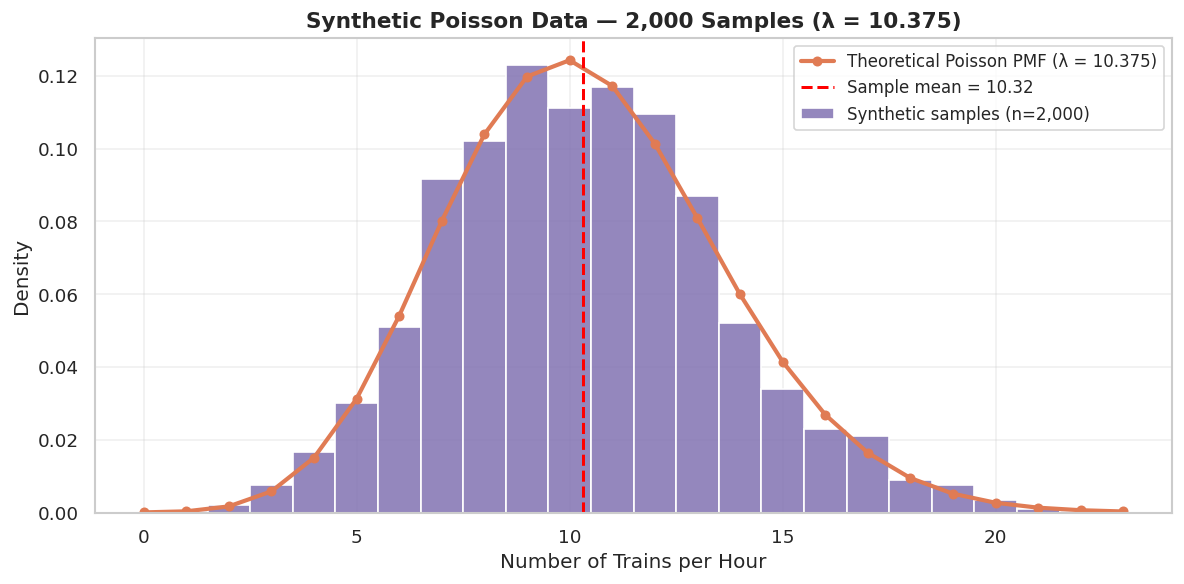

The synthetic distribution closely matches the theoretical Poisson PMF,
confirming the law of large numbers at n = 2000.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x_range = range(0, int(synthetic_data.max()) + 2)
sns.histplot(synthetic_data,
             bins=x_range,
             discrete=True,
             color='#8172B2', edgecolor='white', alpha=0.85,
             stat='density', label='Synthetic samples (n=2,000)', ax=ax)

ax.plot(x_range, poisson.pmf(x_range, mu=mean_updated),
        'o-', color='#E07B54', lw=2.5, ms=5,
        label=f'Theoretical Poisson PMF (λ = {mean_updated})')

ax.axvline(np.mean(synthetic_data), color='red', lw=1.8, linestyle='--',
           label=f'Sample mean = {np.mean(synthetic_data):.2f}')

ax.set_xlabel('Number of Trains per Hour', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Synthetic Poisson Data — 2,000 Samples (λ = 10.375)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("The synthetic distribution closely matches the theoretical Poisson PMF,")
print("confirming the law of large numbers at n = 2000.")


---
## Step 8: Answers to Assignment Questions

### Q1: What is the mean of the initial set of observations?
The mean of the initial 20 observations is **λ = 8.65 trains per hour**.  
This serves as the Poisson rate parameter for all subsequent probability calculations.

### Q2: How does the distribution of the initial observations look? Describe its shape.
The distribution is approximately **bell-shaped and slightly right-skewed**, centred around the mean of 8.65.  
Key characteristics:
- **Unimodal** — single peak at 8–9 trains per hour
- **Discrete** — counts can only be non-negative integers
- **Slightly right-skewed** — for λ ≈ 8.65 the Poisson distribution approaches a normal shape but retains a longer right tail
- **Spread**: values range from 6 to 11, consistent with Poisson variance = λ ≈ 8.65 (σ ≈ 2.94)

### Q3: What are the probabilities of observing more than 9, 10, 11, and 12 trains (initial set)?

| Threshold | Probability | Interpretation |
|---|---|---|
| P(X > 9)  | **0.3666** (36.7%) | ~37 in 100 hours will exceed 9 trains |
| P(X > 10) | **0.2534** (25.3%) | ~25 in 100 hours will exceed 10 trains |
| P(X > 11) | **0.1644** (16.4%) | ~16 in 100 hours will exceed 11 trains |
| P(X > 12) | **0.1003** (10.0%) | ~10 in 100 hours will exceed 12 trains |

The probabilities decrease as the threshold increases — consistent with the Poisson tail becoming thinner for values far above the mean.
